In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

In [2]:
df = pd.read_csv("Nintendo - Wii.csv")

# View basic info
print(df.head())
print(df.info())
print(df.describe())

                                             Name EN       Name CN
0                         Metal Slug Anthology (USA)      合金弹头 精选集
1  Mario Strikers Charged Football (Europe) (En,F...       马里奥激情足球
2      Wii Play (Europe, Australia) (En,Fr,De,Es,It)      Wii第一次接触
3  Monster 4x4 - World Circuit (Europe) (En,Fr,De...  怪物四驱 - 世界巡回赛
4  Link's Crossbow Training (USA) (En,Fr,Es) (Rev 1)       林克的弓箭训练
<class 'pandas.DataFrame'>
RangeIndex: 3778 entries, 0 to 3777
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Name EN  3778 non-null   str  
 1   Name CN  3778 non-null   str  
dtypes: str(2)
memory usage: 300.4 KB
None
                           Name EN Name CN
count                         3778    3778
unique                        3778    1738
top     Metal Slug Anthology (USA)       0
freq                             1      57


In [4]:
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns

for column in cat_cols:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le

In [6]:
target_column = "Target"

if target_column not in df.columns:
    print("Available columns:", df.columns.tolist())
else:
    X = df.drop(columns=[target_column])
    y = df[target_column]

Available columns: ['Name EN', 'Name CN']


In [9]:
print(df.columns)

Index(['Name EN', 'Name CN'], dtype='str')


In [12]:
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

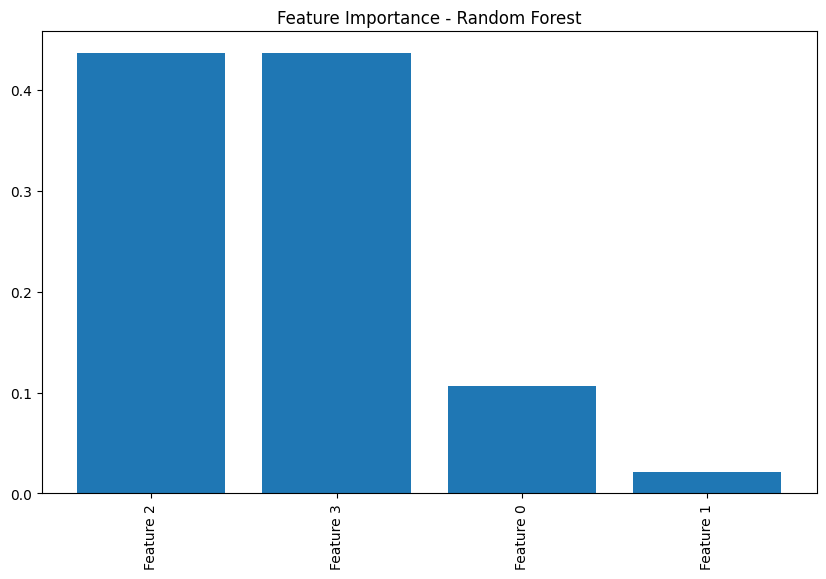

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y)

importances = rf_model.feature_importances_

features = [f"Feature {i}" for i in range(X.shape[1])]

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance - Random Forest")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), np.array(features)[indices], rotation=90)
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Create models
rf_model = RandomForestClassifier(random_state=42)
et_model = ExtraTreesClassifier(random_state=42)

# 3. Train models
rf_model.fit(X_train, y_train)
et_model.fit(X_train, y_train)

# 4. Make predictions
rf_pred = rf_model.predict(X_test)
et_pred = et_model.predict(X_test)

# 5. Evaluate accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Extra Trees Accuracy:", accuracy_score(y_test, et_pred))

Random Forest Accuracy: 1.0
Extra Trees Accuracy: 1.0
